# Targets generation

In [1]:
import numpy as np
from src.targets_generation import Gaussian_seq

In [2]:
N = 500 # number of neurons
T = 10.5 # sequence length (in seconds)
dt = 0.001 # integration step (in seconds)
sigma = np.sqrt(0.3) # width of the gaussian curve
epsilon = 0.05

Choice of sigma: must be bigger than dt and smaller than T. Furthermore, sigma/T ~= N_active/N, which is equal to 0.3 as per the authors.

In [3]:
gs = Gaussian_seq(
    T = T,
    dt = dt
)
targets = gs.target_functions(
    T = T,
    sigma = sigma,
    N = N,
    epsilon = epsilon
)

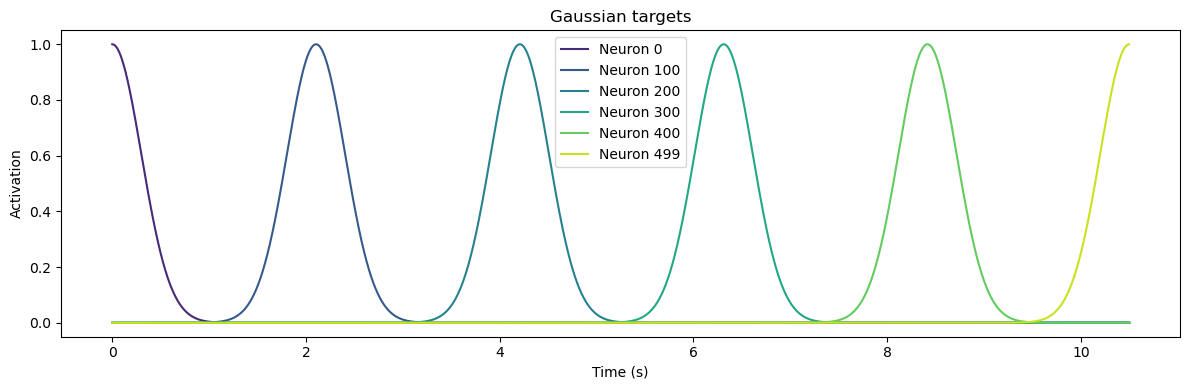

In [4]:
gs.gaussian_graph(
    T = 10.5,
    sigma = 0.3,
    N = 500, 
    neuron_list = [0, 100, 200, 300, 400, 499]
    )

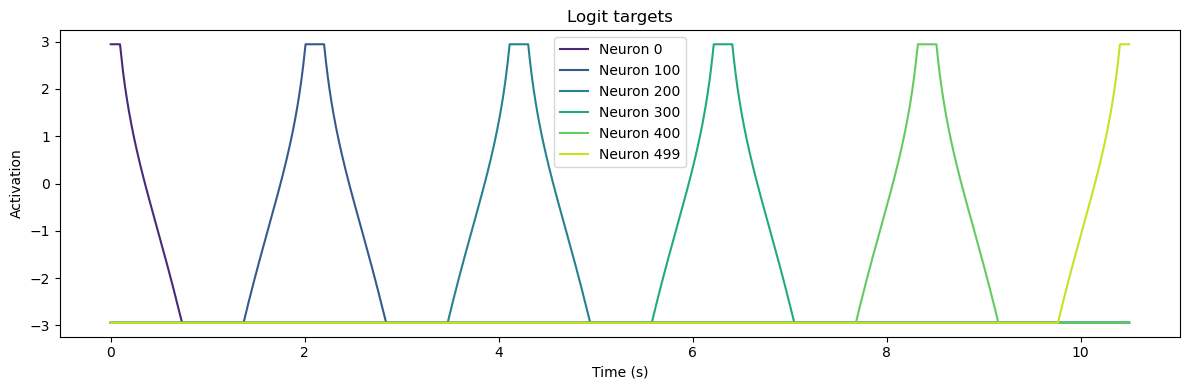

In [5]:
gs.target_graph(
    T = 10.5,
    sigma = 0.3,
    N = 500, 
    neuron_list = [0, 100, 200, 300, 400, 499],
    epsilon = epsilon
    )

# Inputs generation

In [6]:
from src.inputs_generation import Inputs

We define the external inputs of the network as filtered and spatially delocalized white noise, that is frozen, using this equation: \
$\tau_{WN} \displaystyle\frac{dh}{dt} = -h(t) + h_0 \eta (t)$,
for $\eta \sim \mathcal{N}(0, 1)$.

In [7]:
WN_tau = 1  # inputs' correlation time (in seconds)
h0 = 1 # inputs' scale

In [8]:
ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

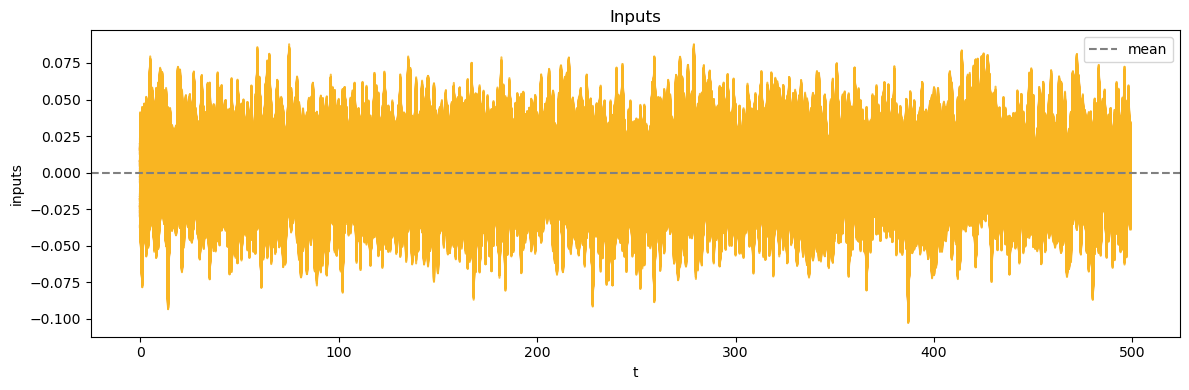

In [9]:
ipt.display_inputs(N, WN_tau, h0)

# Training

In [10]:
from src.training import RNN, PINning

Training parameters, fixed according to Rajan, Harvey & Tank (2016).

In [14]:
p = 0.08 # fraction of plastic synapses in the network
g = 1.5 # chaos parameter
tau = 0.01 # membrane time constant (in seconds)
theta = 0 # sigmoid threshold
p0 = 10 # initial P matrix scaling factor: amplitude of 1 to 10 times h0
n_runs = 500 # number of training steps to learn J
n_steps = 50 # number of additionnal steps where J is not modified
cv_threshold = 0.00 # error value at which we deem the model to converge

Run 1 | run_error=0.038717
Run 2 | run_error=0.071576
Run 3 | run_error=0.137978
Run 4 | run_error=0.131117
Run 5 | run_error=0.094475
Run 6 | run_error=0.077612
Run 7 | run_error=0.069639
Run 8 | run_error=0.058984
Run 9 | run_error=0.079007
Run 10 | run_error=0.057056
Run 11 | run_error=0.060823
Run 12 | run_error=0.049394
Run 13 | run_error=0.075835
Run 14 | run_error=0.067530
Run 15 | run_error=0.068073
Run 16 | run_error=0.049768
Run 17 | run_error=0.043802
Run 18 | run_error=0.058148
Run 19 | run_error=0.048676
Run 20 | run_error=0.099873
Run 21 | run_error=0.091292
Run 22 | run_error=0.074856
Run 23 | run_error=0.060118
Run 24 | run_error=0.071711
Run 25 | run_error=0.073912
Run 26 | run_error=0.075305
Run 27 | run_error=0.065639
Run 28 | run_error=0.052074
Run 29 | run_error=0.050071
Run 30 | run_error=0.047831
Run 31 | run_error=0.084617
Run 32 | run_error=0.084891
Run 33 | run_error=0.087602
Run 34 | run_error=0.041688
Run 35 | run_error=0.064884
Run 36 | run_error=0.051431
R

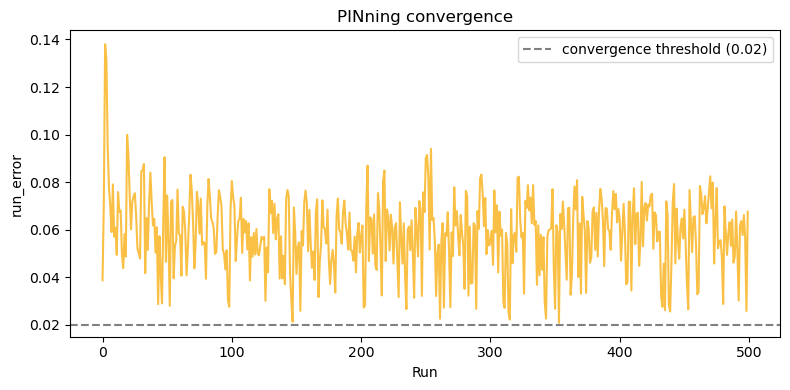

In [15]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True)
# print(np.linalg.eigvalsh(PINned_model.P).min())
PINned_model.display_cv(errors)

In [16]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)

# Evaluation

In [17]:
threshold = 0.95

In [18]:
from src.evaluation import Metrics

In [19]:
from scipy.special import expit
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = gs.t, sigma = sigma, threshold = threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.225672,0.850757,9
1,Article's metrics for p=0.08,1,0.92,10


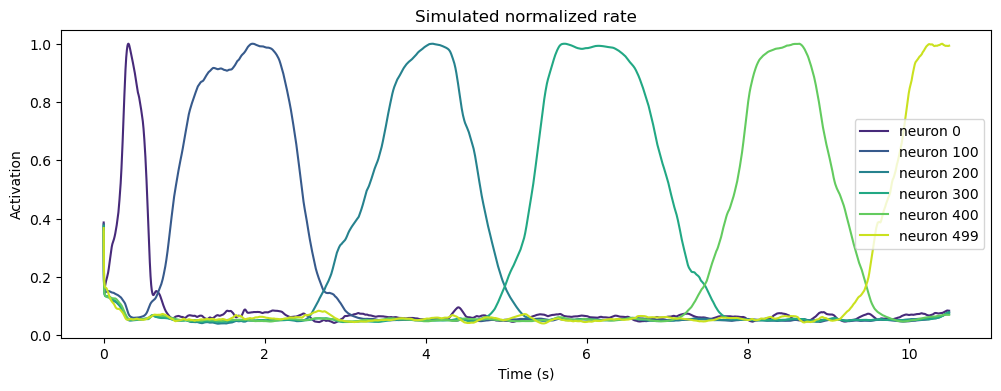

In [20]:
neuron_list = [0, 100, 200, 300, 400, 499]
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

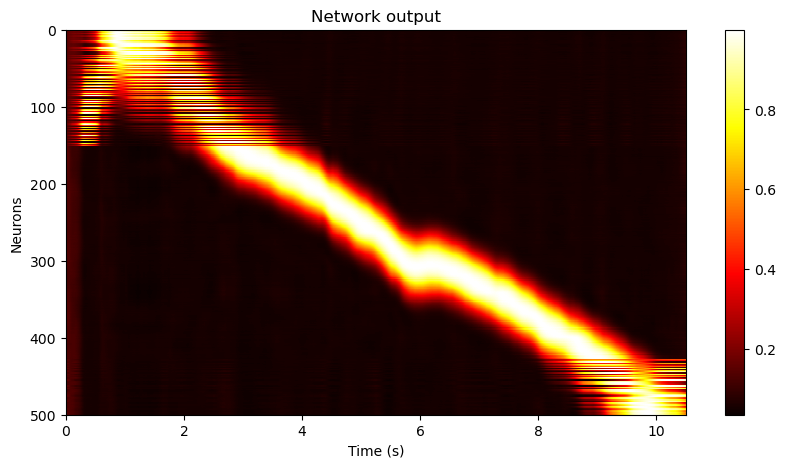

In [21]:
Metrics.network_output(final_rates, T, dt)